In [16]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import sys, os; sys.path.append(os.path.abspath('..'))
from database.db_config import get_engine

## Query for weekdays

In [17]:
query_full_days = "SELECT category, day_of_week, country,salary_avg_pln FROM offers WHERE category= 'IT'"
engine = get_engine()


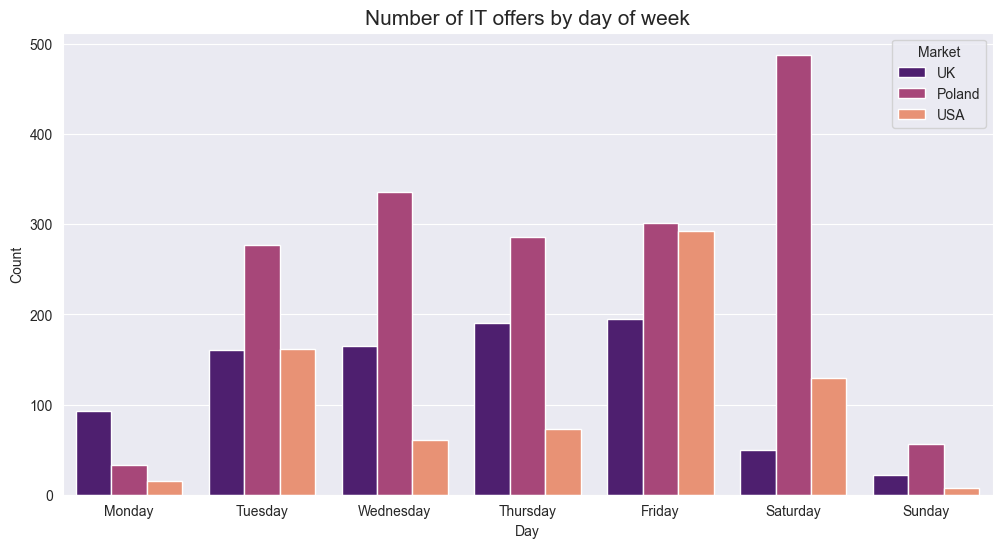

In [18]:
df_analysis = pd.read_sql_query(query_full_days, engine)

df_analysis['country'] = df_analysis['country'].map({'pl': 'Poland', 'us': 'USA', 'gb': 'UK'})

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_analysis['day_of_week'] = pd.Categorical(df_analysis['day_of_week'], categories=days, ordered=True)

plt.figure(figsize=(12, 6))
sns.countplot(data=df_analysis, x='day_of_week', hue='country', palette='magma')

plt.title('Number of IT offers by day of week', fontsize=15)
plt.xlabel('Day')
plt.ylabel('Count')
plt.legend(title='Market') 

## Saturday is the peak for posting in Poland (nearly 500 offers). It strongly suggests an automated re-posting strategy. Both the US and UK markets show a traditional work-week pattern with recruitment peaking on Friday. Monday shows the lowest volume of new postings. 

## Median Salary by day of the week 

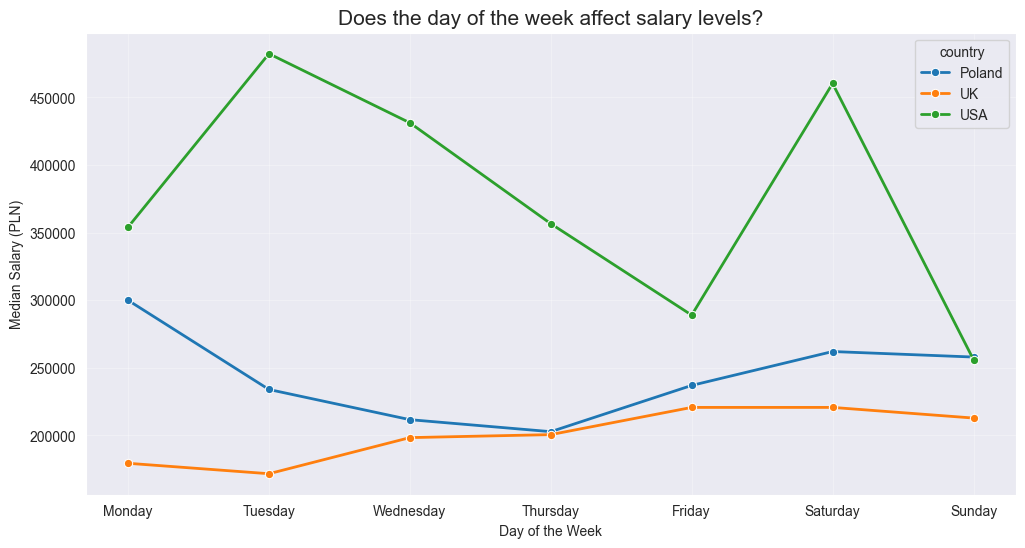

In [19]:
df_analysis['salary_fixed'] = df_analysis['salary_avg_pln'].mask(
    df_analysis['salary_avg_pln'] < 15000, 
    df_analysis['salary_avg_pln'] * 160 * 12
)
salary_day = df_analysis.groupby(['country', 'day_of_week'], observed=False)['salary_fixed'].median().reset_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x='day_of_week', y='salary_fixed', hue='country', data=salary_day, marker='o', linewidth=2)
plt.title('Does the day of the week affect salary levels?', fontsize=15)
plt.ylabel('Median Salary (PLN)')
plt.xlabel('Day of the Week')
plt.grid(True, alpha=0.3)
plt.show()

## The US offers the highest median pay followed by Poland with the UK at the bottom of this specific dataset (huge slary undisclosure for Polish offers). The UK market is the most stable in terms of salary levels.

## Wage Transparency in IT by day

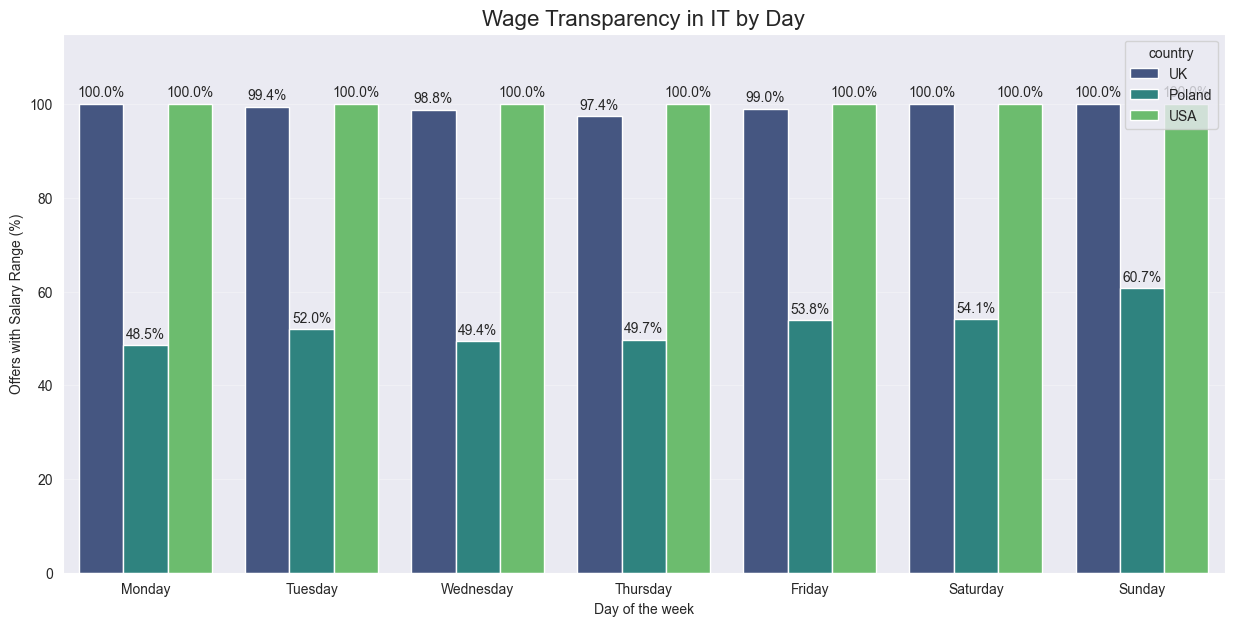

In [20]:
df_analysis['has_salary'] = df_analysis['salary_avg_pln'].notna().astype(float) * 100

plt.figure(figsize=(15, 7))

ax = sns.barplot(data=df_analysis, x='day_of_week', y='has_salary', hue='country', palette='viridis', errorbar=None)
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.bar_label(ax.containers[1], fmt='%.1f%%', padding=3)
ax.bar_label(ax.containers[2], fmt='%.1f%%', padding=3)

plt.title('Wage Transparency in IT by Day', fontsize=16)
plt.ylabel('Offers with Salary Range (%)')
plt.xlabel("Day of the week")
plt.ylim(0, 115) 
plt.grid(axis='y', alpha=0.3)
plt.show()

## Poland exhibits unique recruitment pattern with a massive surge of posting on Sunday. In the USA the transparency is consistenly 100% but there are days for UK that it's not the case 